# **🎯 Problem Discovery & Solution Framing (Checklist 1)**

Tahap ini bertujuan untuk mengidentifikasi permasalahan utama dalam konteks pendidikan serta merumuskan solusi berbasis data yang relevan, terukur, dan berdampak.

---

## **🎯 Problem Statement**

Penurunan performa akademik siswa sering kali tidak terdeteksi sejak dini karena kurangnya sistem pemantauan terintegrasi yang mampu menggabungkan berbagai faktor seperti kehadiran, kebiasaan belajar, motivasi, dan kondisi sosial ekonomi.
Akibatnya, intervensi dari pendidik cenderung bersifat reaktif dan terlambat, sehingga mengurangi efektivitas dalam membantu siswa yang berisiko.

---

## **💡 Solusi yang Diusulkan**

**EduPredict AI** merupakan platform berbasis *machine learning* yang dirancang untuk memprediksi risiko akademik siswa ke dalam tiga kategori: **Rendah, Sedang, dan Tinggi**, berdasarkan 20 variabel dari dataset *Student Performance Factors*.

Sistem ini dilengkapi dengan:
- Model klasifikasi berbasis *Neural Network (TensorFlow)*
- Dashboard interaktif untuk monitoring siswa
- Rekomendasi intervensi berbasis faktor risiko dominan

---

## **✨ Alasan Pemilihan Solusi**

Solusi ini dipilih karena:
- Menggunakan pendekatan **data-driven early warning system**
- Mampu mengintegrasikan berbagai faktor akademik dan non-akademik
- Memberikan output yang **actionable** bagi pendidik

---

## **🔬 Research Questions**

- **RQ1:** Sejauh mana faktor gaya hidup, kehadiran, dan akses teknologi memengaruhi risiko akademik siswa?

- **RQ2:** Seberapa baik model *Neural Network* dalam mengklasifikasikan risiko akademik siswa berdasarkan fitur yang tersedia?

---

## **🎯 Target Kinerja Model**

- Akurasi ≥ **85%**
- Evaluasi tambahan: Precision, Recall, dan F1-Score untuk memastikan keseimbangan performa antar kelas

# **Data Wrangling (Checklist 2)**
Data *Wrangling* merupakan serangkaian proses yang terdiri dari data *gathering* (pengumpulan dan validasi data), data *assesing* (menilai dan melihat kualitas data) dan data *cleaning* (pembersihan data) agar data tersebut dapat ditarik *insight* penting didalamnya.

## **📌 Data Gathering**
Tahap ini bertujuan untuk memuat dataset ke dalam *environment Google Colab* agar dapat dianalisis lebih lanjut.

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "StudentPerformanceFactors.csv"

# Load data
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "lainguyn123/student-performance-factors",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_12148/3513258735.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 627k/627k [00:00<00:00, 1.28MB/s]

First 5 records:    Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \

## **📖 Data Dictionary**
Berikut adalah penjelasan dari setiap variabel (kolom) dalam dataset
*Student Performance Factors* yang digunakan dalam proyek EduPredict AI.
Dataset ini terdiri dari **6.607 baris** dan **20 kolom fitur**
dengan 1 kolom target tambahan (`Risk_Category`) yang dibuat pada
tahap Data Cleaning.

---

### Fitur Numerik

| Kolom | Tipe | Rentang | Deskripsi |
|---|---|---|---|
| `Hours_Studied` | int64 | 1–44 (asli), 4–36 (setelah capping) | Jumlah jam belajar siswa per minggu di luar jam sekolah formal |
| `Attendance` | int64 | 60–100 | Persentase kehadiran siswa di kelas (%) |
| `Sleep_Hours` | int64 | 4–10 | Rata-rata jam tidur siswa per malam |
| `Previous_Scores` | int64 | 50–100 | Nilai ujian atau rapor dari periode sebelumnya |
| `Tutoring_Sessions` | int64 | 0–8 (asli), 0–3 (setelah capping) | Jumlah sesi bimbingan belajar (les) yang diikuti per bulan |
| `Physical_Activity` | int64 | 0–6 | Jumlah jam aktivitas fisik per minggu |
| `Exam_Score` | int64 | 55–100 | Nilai ujian akhir siswa — digunakan sebagai dasar pembuatan label target |

---

### Fitur Kategorikal

| Kolom | Tipe | Nilai Unik | Deskripsi |
|---|---|---|---|
| `Parental_Involvement` | object | Low, Medium, High | Tingkat keterlibatan orang tua dalam kegiatan belajar anak |
| `Access_to_Resources` | object | Low, Medium, High | Ketersediaan akses ke sumber belajar (buku, alat tulis, dll.) |
| `Extracurricular_Activities` | object | Yes, No | Apakah siswa mengikuti kegiatan ekstrakurikuler |
| `Motivation_Level` | object | Low, Medium, High | Tingkat motivasi belajar siswa yang diamati |
| `Internet_Access` | object | Yes, No | Apakah siswa memiliki akses internet di rumah |
| `Family_Income` | object | Low, Medium, High | Kategori tingkat pendapatan keluarga siswa |
| `Teacher_Quality` | object | Low, Medium, High | Penilaian kualitas pengajaran guru (terdapat 78 missing value, diimputasi dengan modus "Medium") |
| `School_Type` | object | Public, Private | Jenis sekolah yang dihadiri siswa |
| `Peer_Influence` | object | Positive, Neutral, Negative | Pengaruh lingkungan pertemanan terhadap perilaku belajar siswa |
| `Learning_Disabilities` | object | Yes, No | Apakah siswa memiliki kesulitan belajar yang terdiagnosis |
| `Parental_Education_Level` | object | High School, College, Postgraduate | Tingkat pendidikan tertinggi orang tua (terdapat 90 missing value, diimputasi dengan modus "High School") |
| `Distance_from_Home` | object | Near, Moderate, Far | Jarak tempat tinggal siswa ke sekolah (terdapat 67 missing value, diimputasi dengan modus "Near") |
| `Gender` | object | Male, Female | Jenis kelamin siswa |

---

### Kolom Target (dibuat pada tahap Data Cleaning)

| Kolom | Tipe | Nilai | Deskripsi |
|---|---|---|---|
| `Risk_Category` | category | High, Medium, Low | Label risiko akademik siswa yang diturunkan dari `Exam_Score` menggunakan threshold domain pendidikan: **Tinggi** (< 60), **Sedang** (60–70), **Rendah** (> 70) |

---

> **Catatan:** Kolom `Exam_Score` tetap dipertahankan di dataset untuk keperluan
> referensi dan EDA, namun **wajib di-drop** dari fitur input saat proses training
> model oleh tim AI Engineer untuk menghindari *data leakage*.

## **🔍 Data Assessing**
Pada tahap ini dilakukan eksplorasi awal seperti pengecekan informasi dataset (baris, kolom, tipe data), statistik deskriptif, deteksi *missing value*, duplikasi, dan *outlier*, serta menampilkan histogram distribusi data mentah untuk memahami struktur, kualitas, dan karakteristik dataset.



In [ ]:
# melihat 5 data pertama
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# melihat informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
# melihat jumlah baris dan kolom pada data (baris, kolom)
df.shape

(6607, 20)

### **📊 Interpretasi: Struktur Dataset**

Dataset terdiri dari **6.607 baris** dan **20 kolom**, yang mencakup:

- **7 fitur numerik (int64)**: `Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`, dan `Exam_Score`.
- **13 fitur kategorikal (object)**: seperti `Parental_Involvement`, `Access_to_Resources`, `Family_Income`, `Teacher_Quality`, `School_Type`, `Gender`, dan lainnya.

**🔍 Temuan Awal**

Dataset memiliki kombinasi fitur numerik dan kategorikal yang cukup beragam, sehingga memerlukan penanganan berbeda dalam proses preprocessing.

**🎯 Implikasi**

Diperlukan langkah data cleaning lanjutan, khususnya pada fitur kategorikal serta pengecekan kualitas data sebelum digunakan dalam analisis berikutnya.

In [ ]:
# melihat statistik deskriptif (mean, standar deviasi, dll)
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


In [ ]:
# mengecek nilai unik untuk kolom kategorikal untuk memastikan tidak ada typo
df.select_dtypes('object').apply(lambda x: x.unique())

,0
Parental_Involvement,"[Low, Medium, High]"
Access_to_Resources,"[High, Medium, Low]"
Extracurricular_Activities,"[No, Yes]"
Motivation_Level,"[Low, Medium, High]"
Internet_Access,"[Yes, No]"
Family_Income,"[Low, Medium, High]"
Teacher_Quality,"[Medium, High, Low, nan]"
School_Type,"[Public, Private]"
Peer_Influence,"[Positive, Negative, Neutral]"
Learning_Disabilities,"[No, Yes]"


### **📊 Interpretasi: Statistik Deskriptif**

#### 🔢 Fitur Numerik

Secara umum, distribusi fitur numerik berada dalam rentang yang wajar dan masih masuk akal secara logis:

- **Hours_Studied** memiliki rata-rata sekitar **20 jam/minggu** dengan rentang **1–44 jam**. Nilai maksimum tergolong tinggi, namun masih memungkinkan secara realistis sehingga tidak langsung dianggap sebagai error.
  
- **Attendance** rata-rata **80%** dengan rentang **60–100%**, menunjukkan variasi tingkat kehadiran yang cukup lebar.

- **Sleep_Hours** rata-rata **7 jam** (normal), dengan rentang **4–10 jam**, tanpa indikasi nilai ekstrem yang mencurigakan.

- **Previous_Scores** memiliki rata-rata dan median yang sama (**75**), mengindikasikan distribusi yang relatif simetris.

- **Tutoring_Sessions** umumnya berada pada **1–2 sesi**, namun terdapat nilai hingga **8 sesi** yang dapat dikategorikan sebagai outlier, meskipun masih masuk akal secara kontekstual.

- **Physical_Activity** memiliki rata-rata **3** dari skala **0–6**, menunjukkan tingkat aktivitas fisik yang moderat.

- **Exam_Score** memiliki rata-rata **67,24** dengan rentang **55–101**. Nilai maksimum **101** tidak lazim dan mengindikasikan kemungkinan **data entry error**, sehingga perlu penanganan lebih lanjut pada tahap cleaning.

---

#### 🏷️ Fitur Kategorikal

Fitur kategorikal menunjukkan distribusi yang relatif konsisten dan sesuai dengan tipe data yang diharapkan.

- Tidak ditemukan indikasi awal adanya nilai yang tidak konsisten atau kategori yang tidak logis, meskipun pemeriksaan lanjutan tetap diperlukan.

- Beberapa fitur menunjukkan **dominasi kategori tertentu**, seperti:
  - `Internet_Access`: didominasi "Yes"
  - `Learning_Disabilities`: didominasi "No"
  - `School_Type`: didominasi "Public"

- Variabel **Family_Income** didominasi kategori *Low*, diikuti *Medium* dan *High*.

- Beberapa variabel seperti `Parental_Involvement`, `Access_to_Resources`, `Motivation_Level`, dan `Teacher_Quality` cenderung terkonsentrasi pada kategori *Medium*.

- `Distance_from_Home` didominasi kategori *Near*, sementara `Gender` relatif seimbang antara laki-laki dan perempuan.

---

### 🔍 Temuan Awal

- Terdapat indikasi **nilai tidak valid** pada `Exam_Score` yang melebihi batas normal.
- Beberapa fitur kategorikal mengalami **ketidakseimbangan distribusi (imbalance)**.
- Outlier pada beberapa fitur numerik masih dalam batas logis dan tidak langsung memerlukan penghapusan.

---

### 🎯 Implikasi

- Perlu dilakukan **data cleaning** untuk menangani nilai tidak valid pada `Exam_Score`.
- Ketidakseimbangan pada fitur kategorikal perlu diperhatikan karena dapat mempengaruhi performa model.
- Outlier yang masih logis dapat dipertahankan, namun tetap perlu dipertimbangkan dalam tahap analisis lanjutan.

In [ ]:
# melihat baris data yang mengandung inaccurate value
df[df.Exam_Score == df.Exam_Score.max()]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


### **⚠️ Temuan: Nilai Tidak Valid pada Exam_Score**

Ditemukan satu baris data (indeks 1525) dengan nilai **Exam_Score = 101**, yang melebihi batas maksimum umum (100).

### 🔎 Analisis
Nilai ini tidak lazim dan kemungkinan besar merupakan **data entry error** atau kesalahan pencatatan.

### 🎯 Implikasi
Nilai tersebut perlu ditangani pada tahap *data cleaning*, misalnya dengan:
- melakukan koreksi nilai (capping ke 100), atau
- menghapus baris data jika dianggap tidak valid.

Penanganan ini penting untuk menjaga konsistensi data dan mencegah bias dalam analisis maupun pemodelan.

In [ ]:
# melihat missing value pada data
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [ ]:
# melihat detail missing value tiap kolom
# df[df.Teacher_Quality.isna()]

# menampilkan detail missing value dari semua kolom
df.loc[df[['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']].isna().any(axis=1), ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']]


,Teacher_Quality,Parental_Education_Level,Distance_from_Home
33,Medium,College,NaN
127,NaN,High School,Far
240,Medium,NaN,Moderate
275,Medium,High School,NaN
316,Medium,College,NaN
...,...,...,...
6502,High,NaN,Near
6579,NaN,High School,Near
6589,Low,College,NaN
6594,High,High School,NaN


In [ ]:
# menghitung persentase missing value per kolom
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64


### **⚠️ Analisis Missing Value**

Dari total 20 kolom dalam dataset, sebanyak **17 kolom memiliki data lengkap** (tanpa missing value), sementara **3 kolom kategorikal** mengandung nilai kosong, yaitu:

- **Teacher_Quality**: 78 nilai kosong (~1,18%)
- **Parental_Education_Level**: 90 nilai kosong (~1,36%)
- **Distance_from_Home**: 67 nilai kosong (~1,01%)

Secara keseluruhan, terdapat **229 baris** yang memiliki missing value pada setidaknya salah satu dari ketiga kolom tersebut.

---

### 🔍 Temuan Awal
Proporsi missing value pada masing-masing kolom tergolong **kecil (<2%)**, sehingga tidak terlalu signifikan terhadap keseluruhan dataset.

---

### 🎯 Implikasi
Dengan proporsi missing yang relatif rendah, penanganan dilakukan menggunakan pendekatan imputasi.

Untuk variabel **Teacher_Quality**, digunakan metode *group-based imputation* dengan mempertimbangkan variabel **School_Type**, karena kualitas pengajaran cenderung berkaitan dengan jenis sekolah.

Sementara itu, variabel kategorikal lainnya ditangani menggunakan **modus global**, karena tidak ditemukan indikasi hubungan kuat dengan variabel lain.

Pendekatan ini bertujuan untuk menjaga konsistensi data sekaligus mempertahankan pola yang ada dalam dataset.

In [ ]:
# melihat jumlah duplikasi data
print("Jumlah Data Duplikat:", df.duplicated().sum())

Jumlah Data Duplikat: 0


In [ ]:
# melihat data dengan nilai negatif (<0)
numeric_df = df.select_dtypes(include=np.number)
display(numeric_df[numeric_df < 0])

print()
print(f'Data dengan nilai negatif:\n{numeric_df[numeric_df<0].sum()}')


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
6602,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6605,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Data dengan nilai negatif:
Hours_Studied        0.0
Attendance           0.0
Sleep_Hours          0.0
Previous_Scores      0.0
Tutoring_Sessions    0.0
Physical_Activity    0.0
Exam_Score           0.0
dtype: float64


### **🔍 Validasi Data: Duplikasi & Nilai Tidak Wajar**

- **Jumlah Data Duplikat: 0**  
  Tidak ditemukan baris data yang identik di seluruh dataset. Hal ini menunjukkan bahwa setiap observasi bersifat unik, sehingga tidak diperlukan proses penghapusan duplikasi.

- **Nilai Negatif pada Fitur Numerik: 0**  
  Tidak ditemukan nilai negatif pada seluruh kolom numerik (`Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`, dan `Exam_Score`).

---

### 🔎 Temuan Awal
Secara umum, nilai pada fitur numerik berada dalam rentang yang logis dan sesuai konteks. Namun, terdapat indikasi nilai tidak valid pada `Exam_Score` (melebihi batas maksimum), yang telah diidentifikasi sebelumnya.

---

### 🎯 Implikasi
- Tidak diperlukan penanganan duplikasi data.  
- Tidak diperlukan koreksi terhadap nilai negatif.  
- Fokus data cleaning selanjutnya dapat diarahkan pada penanganan nilai tidak valid (seperti `Exam_Score`) dan perbaikan kualitas data lainnya.

In [ ]:
# mengecek outlier pada data
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    print(f"{col}: {outliers_count} outliers")

Hours_Studied: 43 outliers
Attendance: 0 outliers
Sleep_Hours: 0 outliers
Previous_Scores: 0 outliers
Tutoring_Sessions: 430 outliers
Physical_Activity: 0 outliers
Exam_Score: 104 outliers


In [ ]:
# fungsi mengecek secara spesifik kolom yang mengandung outlier
outlier_data = {}

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    # simpan
    outlier_data[col] = outliers

In [ ]:
# cek outlier kolom hours_studied
outlier_data['Hours_Studied'] \
    .sort_values(by='Hours_Studied', ascending=False)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
2895,44,68,High,Low,No,9,75,Low,Yes,3,Medium,High,Private,Negative,2,No,High School,Moderate,Female,71
209,43,86,High,Medium,Yes,7,97,Medium,Yes,2,Medium,High,Public,Positive,1,No,High School,Near,Female,78
1615,39,95,Medium,High,Yes,9,54,High,Yes,2,Medium,Medium,Private,Positive,3,No,High School,Moderate,Male,77
3982,39,75,Medium,High,Yes,6,82,High,Yes,1,High,Low,Public,Negative,3,No,College,Near,Male,73
3716,39,90,High,High,No,8,92,High,Yes,2,Medium,High,Private,Neutral,1,No,High School,Near,Female,78
4997,39,67,High,High,Yes,5,76,Medium,No,2,Medium,Medium,Private,Negative,4,No,NaN,Near,Female,71
5796,39,78,Medium,Medium,No,6,73,Medium,Yes,0,Low,Medium,Public,Positive,2,No,College,Far,Male,70
2305,39,92,Medium,Medium,No,9,73,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,Postgraduate,Moderate,Male,75
1957,39,97,High,High,Yes,10,91,Medium,Yes,2,Low,Medium,Public,Positive,3,No,High School,Moderate,Female,79
478,38,86,Low,High,Yes,7,79,Low,Yes,3,Low,Medium,Public,Negative,3,No,High School,Near,Male,73


In [ ]:
# cek outlier kolom tutoring_sessions
outlier_data['Tutoring_Sessions'] \
    .sort_values(by='Tutoring_Sessions', ascending=False)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
2231,25,72,Low,Low,Yes,6,78,Low,Yes,8,Medium,High,Public,Positive,4,No,High School,Near,Male,69
1548,25,95,Low,Medium,No,7,78,Medium,Yes,7,Low,Medium,Public,Positive,4,No,High School,Near,Male,73
5680,14,82,Medium,High,No,6,94,Low,Yes,7,Medium,High,Private,Negative,4,No,Postgraduate,Near,Male,71
2346,17,91,High,Low,Yes,10,84,Medium,Yes,7,Low,High,Public,Neutral,4,Yes,College,Moderate,Male,71
4009,24,69,High,Medium,No,7,69,Medium,No,7,High,Medium,Public,Positive,3,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,10,80,High,Medium,Yes,6,93,High,Yes,4,Medium,NaN,Public,Negative,3,No,College,Moderate,Female,67
389,17,74,Medium,Medium,Yes,8,87,Medium,Yes,4,Low,Low,Public,Positive,3,No,College,Near,Male,67
369,15,80,Low,High,No,5,90,Medium,Yes,4,Low,Medium,Public,Positive,3,No,College,Far,Female,67
345,21,99,Medium,Medium,No,8,85,High,Yes,4,Medium,Medium,Public,Positive,4,No,High School,Moderate,Male,73


In [ ]:
# cek outlier kolom exam_score
outlier_data['Exam_Score'] \
    .sort_values(by='Exam_Score', ascending=False)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
2425,23,83,High,High,Yes,4,89,Low,Yes,1,Medium,Medium,Public,Negative,3,No,High School,Far,Male,99
3579,14,90,High,High,Yes,8,86,Medium,Yes,4,Medium,Medium,Private,Negative,2,No,High School,Near,Female,99
6347,28,96,High,Low,Yes,4,98,High,Yes,1,High,High,Public,Positive,3,No,High School,Near,Male,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2880,7,66,High,Low,Yes,8,68,High,Yes,0,Low,Medium,Public,Negative,2,Yes,College,Moderate,Male,57
5907,3,60,Medium,Low,Yes,6,78,Low,Yes,1,Low,Medium,Public,Positive,1,No,Postgraduate,Near,Female,57
5719,9,64,Medium,Low,Yes,10,68,Low,Yes,0,Medium,Medium,Private,Negative,3,No,High School,Near,Male,57
5507,5,65,Low,High,No,7,71,Medium,Yes,0,Low,Medium,Private,Negative,2,No,College,Far,Male,56


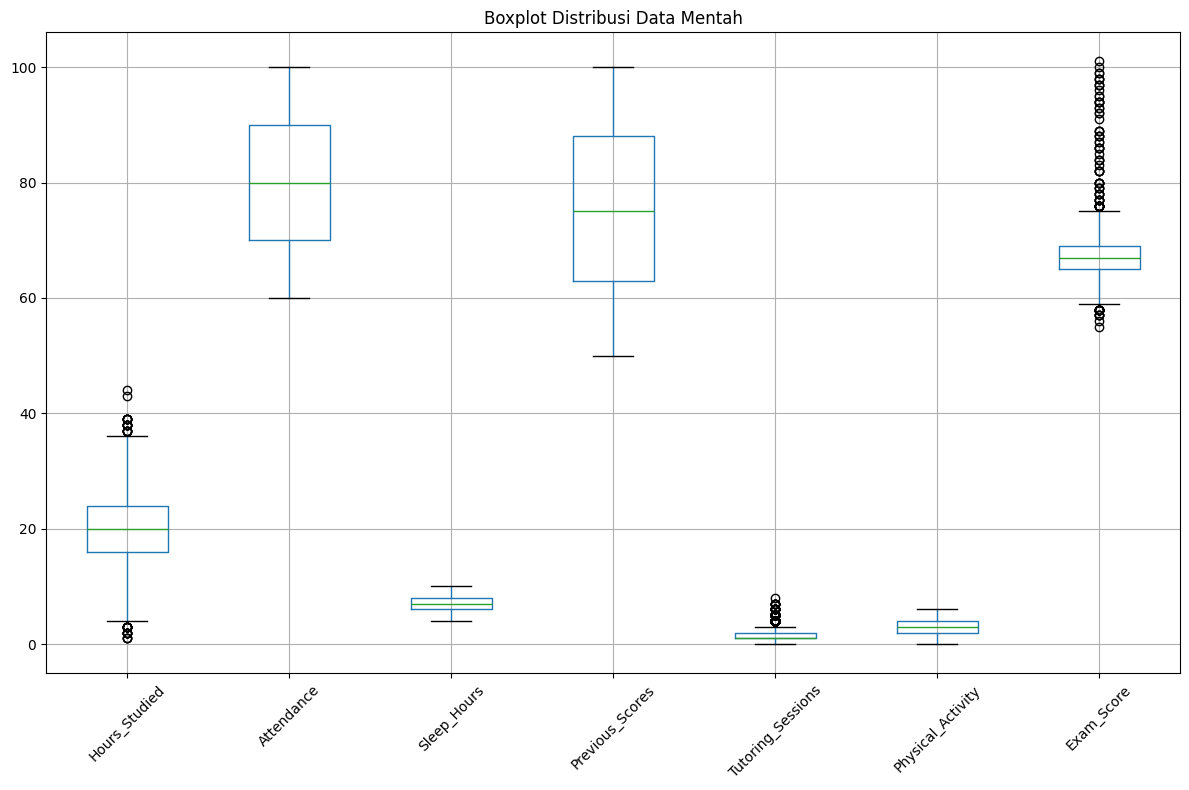

In [ ]:
# memilih kolom numerik
numerical_cols = df.select_dtypes(include='number').columns

# atur ukuran
plt.figure(figsize=(12, 8))

# boxplot vertikal untuk setiap kolom
df[numerical_cols].boxplot(figsize=(12, 8), rot=45)
plt.title('Boxplot Distribusi Data Mentah')
plt.tight_layout()
plt.show()

### **⚠️ Analisis Outlier (Metode IQR)**

Berdasarkan deteksi menggunakan metode Interquartile Range (IQR), ditemukan outlier pada beberapa fitur numerik sebagai berikut:

- **Hours_Studied**: 43 outlier  
- **Tutoring_Sessions**: 430 outlier  
- **Exam_Score**: 104 outlier  
- Fitur lainnya tidak menunjukkan adanya outlier signifikan.

---

### 🔍 Temuan Awal

- **Hours_Studied** memiliki outlier pada nilai yang sangat rendah (1–3 jam/minggu) dan sangat tinggi (37–44 jam/minggu). Meskipun tergolong ekstrem secara statistik, nilai-nilai ini masih mungkin terjadi dalam konteks nyata.

- **Tutoring_Sessions** memiliki jumlah outlier yang cukup besar, terutama pada nilai tinggi (7–8 sesi), jauh di atas rata-rata (1–2 sesi). Hal ini menunjukkan adanya distribusi yang tidak merata pada variabel ini.

- **Exam_Score** memiliki outlier pada nilai sangat tinggi (99–101) dan rendah (55–57). Nilai 101 sebelumnya telah diidentifikasi sebagai kemungkinan **data entry error**, sedangkan nilai rendah masih berada dalam batas yang mungkin terjadi.

---

### 🎯 Implikasi

- Tidak semua outlier perlu dihapus, terutama jika masih masuk akal secara kontekstual.  
- Outlier pada **Hours_Studied** dan sebagian besar **Tutoring_Sessions** dapat dipertahankan, namun tetap perlu dipertimbangkan dalam analisis lanjutan.  
- Outlier pada **Exam_Score**, khususnya nilai di atas 100, perlu ditangani karena berpotensi merupakan kesalahan data.  
- Untuk menjaga stabilitas distribusi dan mengurangi pengaruh nilai ekstrem, dapat dipertimbangkan penggunaan teknik seperti *capping* pada tahap data cleaning.

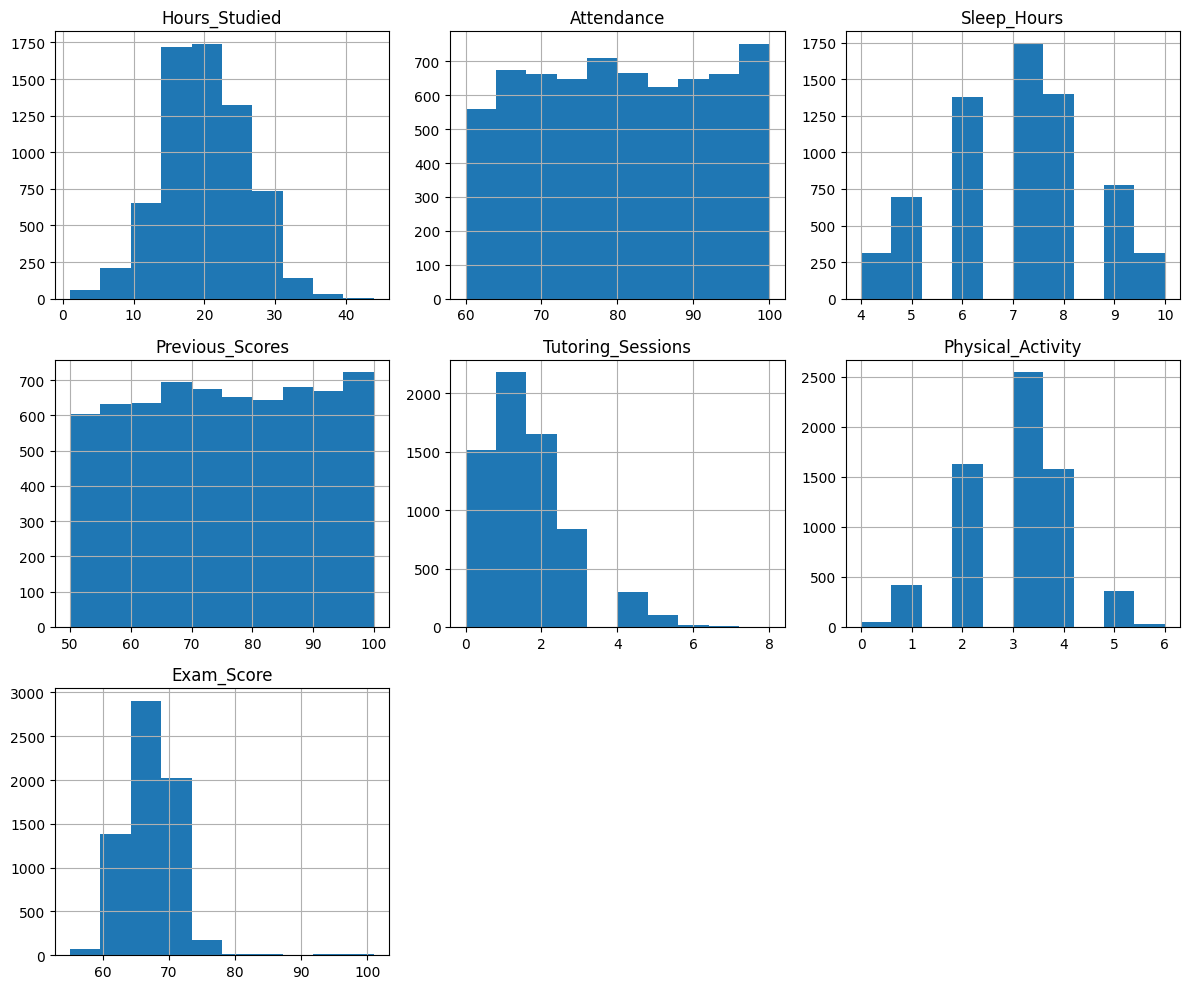

In [ ]:
# menampilkan grafik histogram (distribusi penyebaran data)
df.hist(figsize=(12, 10), layout=(3,3))
plt.tight_layout()
plt.show()

### **📌 Ringkasan Data Assessing**

Berdasarkan hasil eksplorasi dan evaluasi kualitas data, diperoleh beberapa temuan utama sebagai berikut:

### 🔍 Struktur Dataset
Dataset terdiri dari **6.607 baris** dan **20 kolom**, yang mencakup **7 fitur numerik** dan **13 fitur kategorikal**. Komposisi ini menunjukkan bahwa dataset memiliki variasi tipe data yang cukup untuk analisis lebih lanjut.

---

### ⚠️ Permasalahan Data yang Ditemukan

- **Missing Value**  
  Ditemukan nilai kosong pada 3 kolom kategorikal:
  - `Teacher_Quality` (78 data)
  - `Parental_Education_Level` (90 data)
  - `Distance_from_Home` (67 data)  
  Proporsinya relatif kecil (<2%), sehingga masih dapat ditangani dengan metode imputasi tanpa menghapus data.

- **Nilai Tidak Valid**  
  Terdapat nilai **Exam_Score = 101**, yang melebihi batas maksimum umum (100), sehingga diindikasikan sebagai kesalahan input.

- **Outlier**  
  Outlier terdeteksi pada:
  - `Hours_Studied` (43 data)
  - `Tutoring_Sessions` (430 data)
  - `Exam_Score` (104 data)  
  Sebagian besar outlier masih dalam batas logis, namun tetap perlu dikontrol untuk menjaga stabilitas distribusi.

---

### ✅ Validasi Data
- Tidak ditemukan **data duplikat**  
- Tidak terdapat **nilai negatif** pada seluruh fitur numerik  

Hal ini menunjukkan bahwa secara umum kualitas data cukup baik dan tidak memerlukan penanganan pada aspek tersebut.

---

### 🎯 Implikasi
Secara keseluruhan, dataset berada dalam kondisi yang cukup baik, dengan beberapa isu utama yang perlu ditangani pada tahap data cleaning, yaitu:
- Imputasi missing value  
- Perbaikan nilai tidak valid  
- Penanganan outlier  

Setelah proses tersebut dilakukan, dataset akan lebih siap untuk tahap merumuskan pertanyaan bisnis, Exploration Data Analysis (EDA) dan pemodelan.

## **🧹 Data Cleaning**
Pada tahap ini, setelah ditemukan deteksi *missing value* dan *outlier* pada proses *assesing*, data mentah dibersihkan dan dipersiapkan agar siap dianalisis. Proses mencakup penanganan nilai kosong (*missing values*) dan penanganan deteksi *outlier*.

In [ ]:
# mengganti nilai inaccurate data pada nilai max exam_score (asumsi kesalahan input)
df['Exam_Score'] = df['Exam_Score'].replace(df['Exam_Score'].max(), 100)

In [ ]:
# mengecek ulang inaccurate data pada nilai max exam_score
df[df.Exam_Score == df.Exam_Score.max()]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,100


### **🧹 Interpretasi: Perbaikan Nilai Tidak Valid (Exam_Score)**

1. **Penggantian Nilai Maksimum (101 → 100)**  
Nilai maksimum pada kolom `Exam_Score` yang sebelumnya bernilai **101** (indeks 1525) telah diperbaiki menjadi **100**, sesuai dengan batas maksimum yang umum digunakan.

2. **Hasil Pengecekan Ulang Nilai Maksimum**  
Setelah dilakukan perbaikan, nilai maksimum pada kolom `Exam_Score` kini adalah **100**, dengan total **2 baris data** yang memiliki nilai tersebut.

---

### 🔍 Validasi Hasil Cleaning
- Tidak ditemukan lagi nilai `Exam_Score` yang melebihi batas maksimum.
- Distribusi nilai pada kolom `Exam_Score` menjadi lebih konsisten dan sesuai dengan konteks data.

---

### 🎯 Implikasi
- Perbaikan ini menghilangkan potensi **bias akibat nilai tidak valid** dalam analisis statistik maupun pemodelan.
- Dataset kini lebih representatif terhadap kondisi nyata, sehingga hasil analisis selanjutnya menjadi lebih dapat dipercaya.

In [ ]:
# menangani missing value dengan group based imputation dengan pertimbangan variabel school_type
for col in ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']:
    if col == 'Teacher_Quality':
        df[col] = df.groupby('School_Type')[col].transform(
            lambda x: x.fillna(x.mode()[0] if not x.mode().empty else df[col].mode()[0])
        )
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
# mengecek ulang nilai missing value
missing = df.isnull().sum().to_frame(name='Jumlah Missing Value')

display(missing)

if (missing['Jumlah Missing Value'] == 0).all():
    print("\n✅ Tidak ada missing value pada dataset.")
else:
    print("\n⚠️ Dataset masih memiliki missing value.")

,Jumlah Missing Value
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0



✅ Tidak ada missing value pada dataset.


In [ ]:
# menghitung ulang persentase missing value per kolom
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Hours_Studied                 0.0
Attendance                    0.0
Parental_Involvement          0.0
Access_to_Resources           0.0
Extracurricular_Activities    0.0
Sleep_Hours                   0.0
Previous_Scores               0.0
Motivation_Level              0.0
Internet_Access               0.0
Tutoring_Sessions             0.0
Family_Income                 0.0
Teacher_Quality               0.0
School_Type                   0.0
Peer_Influence                0.0
Physical_Activity             0.0
Learning_Disabilities         0.0
Parental_Education_Level      0.0
Distance_from_Home            0.0
Gender                        0.0
Exam_Score                    0.0
dtype: float64


### **🧹 Interpretasi: Penanganan Missing Value**

Missing value pada variabel `Teacher_Quality` ditangani menggunakan pendekatan berbasis kelompok (*group-based imputation*) dengan mempertimbangkan variabel `School_Type`. Pendekatan ini digunakan karena kualitas pengajaran cenderung dipengaruhi oleh jenis sekolah, sehingga imputasi berbasis kelompok dianggap lebih representatif.

Sementara itu, variabel kategorikal lainnya (`Parental_Education_Level` dan `Distance_from_Home`) ditangani menggunakan **modus global**, karena tidak ditemukan indikasi hubungan kuat dengan variabel lain.

---

### 🔍 Validasi Hasil Cleaning

Berdasarkan hasil pengecekan ulang:

- Seluruh kolom dalam dataset memiliki **0 missing value**
- Persentase missing value pada setiap kolom adalah **0%**

Hal ini menunjukkan bahwa proses imputasi telah berhasil dilakukan secara menyeluruh tanpa menyisakan data yang hilang.

---

### 🎯 Implikasi

- Dataset kini berada dalam kondisi **lengkap (complete data)** dan siap digunakan untuk analisis lanjutan.
- Tidak diperlukan penghapusan data, sehingga seluruh informasi tetap dipertahankan.
- Kualitas data meningkat dan lebih konsisten, yang dapat mendukung performa analisis maupun pemodelan yang lebih optimal.

In [ ]:
# menangani outlier: menggunakan metode capping
# nilai outlier diganti dengan batas bawah/atas sesuai dengan kolom yang memiliki outlier
outlier_cols = ['Hours_Studied', 'Tutoring_Sessions']

df_capped = df.copy()

for col in outlier_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    print(f"{col}: outlier di-capped ke rentang [{lower:.2f}, {upper:.2f}]")

Hours_Studied: outlier di-capped ke rentang [4.00, 36.00]
Tutoring_Sessions: outlier di-capped ke rentang [-0.50, 3.50]


In [ ]:
# mengecek ulang outlier gunakan df_capped (hasil capping)
print("Jumlah Outlier Setelah Penanganan dengan Metode Capping")
for col in outlier_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = df_capped[(df_capped[col] < lower) | (df_capped[col] > upper)].shape[0]
    print(f"{col}: {outliers_count} outliers")

Jumlah Outlier Setelah Penanganan dengan Metode Capping
Hours_Studied: 0 outliers
Tutoring_Sessions: 0 outliers


In [ ]:
# Menetapkan df_clean sebagai dataset yang akan digunakan untuk EDA dan Modeling
df_clean = df_capped.copy()

print("Dataset final 'df_clean' telah disiapkan.")
print(f"Jumlah baris: {df_clean.shape[0]}")
print(f"Fitur yang di-capping: Hours_Studied, Tutoring_Sessions")

Dataset final 'df_clean' telah disiapkan.
Jumlah baris: 6607
Fitur yang di-capping: Hours_Studied, Tutoring_Sessions


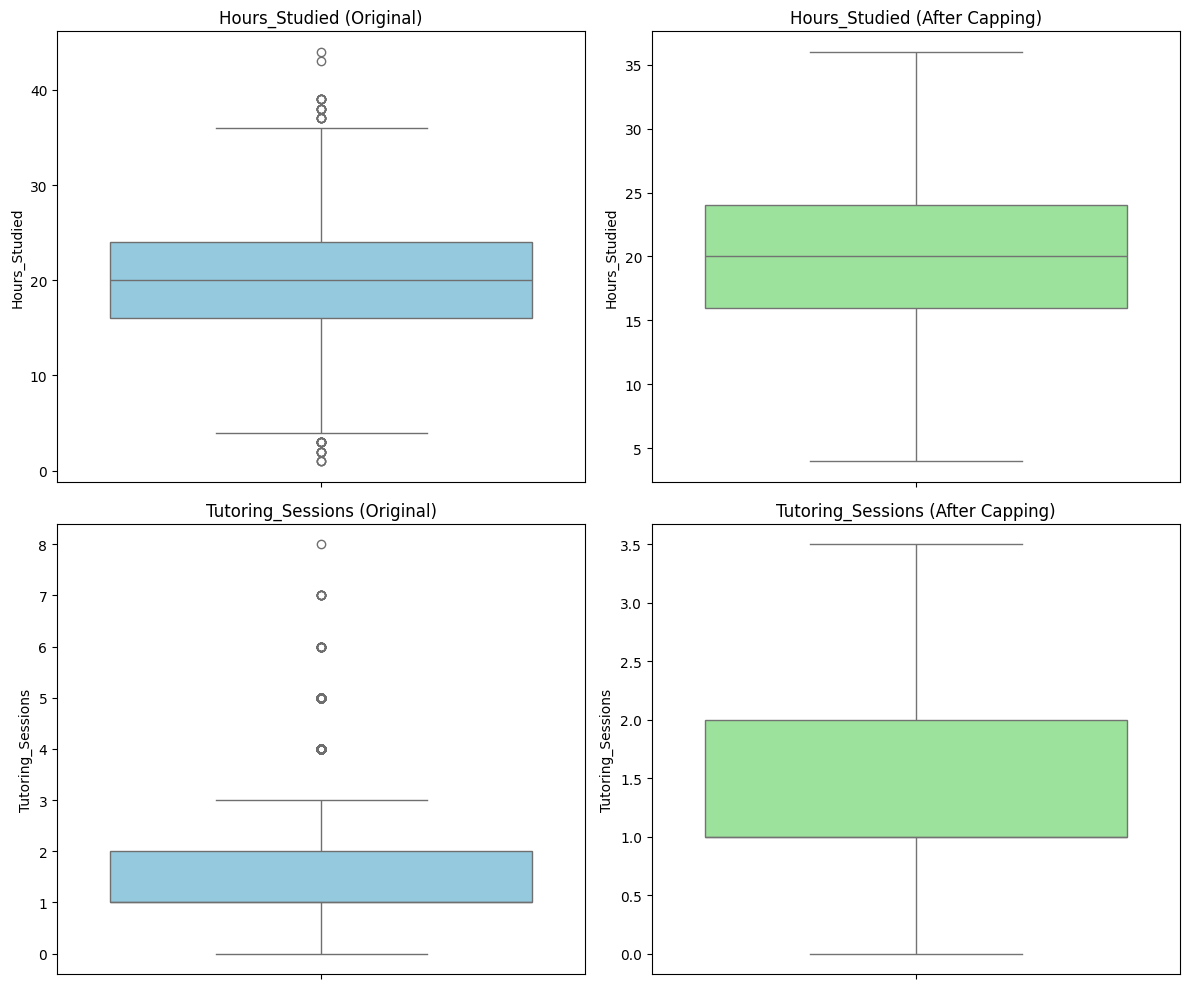

In [ ]:
# visualisasi perbandingan sebelum dan sesudah capping
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Hours_Studied - Original
sns.boxplot(y=df['Hours_Studied'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Hours_Studied (Original)')

# Hours_Studied - After Capping
sns.boxplot(y=df_clean['Hours_Studied'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Hours_Studied (After Capping)')

# Tutoring_Sessions - Original
sns.boxplot(y=df['Tutoring_Sessions'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Tutoring_Sessions (Original)')

# Tutoring_Sessions - After Capping
sns.boxplot(y=df_clean['Tutoring_Sessions'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Tutoring_Sessions (After Capping)')

plt.tight_layout()
plt.show()

In [ ]:
# membandingkan rentang nilai (min & max) untuk data yang mengandung outlier
comparison = pd.DataFrame({
    'Kolom': ['Hours_Studied', 'Tutoring_Sessions', 'Exam_Score'],
    'Min (Original)': [df['Hours_Studied'].min(), df['Tutoring_Sessions'].min(), df['Exam_Score'].min()],
    'Max (Original)': [df['Hours_Studied'].max(), df['Tutoring_Sessions'].max(), df['Exam_Score'].max()],
    'Min (Cleaned)': [df_clean['Hours_Studied'].min(), df_clean['Tutoring_Sessions'].min(), df_clean['Exam_Score'].min()],
    'Max (Cleaned)': [df_clean['Hours_Studied'].max(), df_clean['Tutoring_Sessions'].max(), df_clean['Exam_Score'].max()]
})

display(comparison)

,Kolom,Min (Original),Max (Original),Min (Cleaned),Max (Cleaned)
0,Hours_Studied,1,44,4.0,36.0
1,Tutoring_Sessions,0,8,0.0,3.5
2,Exam_Score,55,100,55.0,100.0


### **🧹 Interpretasi: Penanganan Outlier (Metode Capping / Winsorizing)**

Outlier pada fitur numerik ditangani menggunakan metode **capping (Winsorizing)** berbasis batas Interquartile Range (IQR).

- `Hours_Studied` di-capping ke rentang **[4.00, 36.00]**
- `Tutoring_Sessions` di-capping ke rentang **[0.00, 3.50]**

Setelah dilakukan capping, hasil pengecekan menunjukkan bahwa:
- **Hours_Studied: 0 outlier**
- **Tutoring_Sessions: 0 outlier**

Hal ini menandakan bahwa nilai ekstrem telah berhasil dikendalikan tanpa menghapus data.

---

### 🔍 Validasi Hasil Cleaning

Perbandingan sebelum dan sesudah capping menunjukkan:
- Nilai maksimum pada `Hours_Studied` berubah dari **44 → 36**
- Nilai maksimum pada `Tutoring_Sessions` berubah dari **8 → 3.5**
- Rentang nilai menjadi lebih terkontrol dan tidak lagi mengandung outlier ekstrem

Sementara itu:
- `Exam_Score` tetap berada pada rentang **55–100** dan **tidak dilakukan capping**

---

### ⚠️ Pertimbangan Khusus (Exam_Score)

Kolom `Exam_Score` tidak dilakukan capping karena berperan sebagai **variabel target (label)** dalam analisis.

Melakukan capping pada variabel target berpotensi:
- Menghilangkan variasi alami data
- Mengurangi representasi performa nyata siswa

Nilai ekstrem seperti skor rendah (55) atau tinggi (100) masih dianggap valid secara kontekstual, sehingga tetap dipertahankan. Satu-satunya nilai tidak valid (101) telah diperbaiki pada tahap sebelumnya.

---

### 🎯 Implikasi

- Capping pada fitur input (`Hours_Studied`, `Tutoring_Sessions`) membantu mengurangi pengaruh nilai ekstrem terhadap distribusi data dan meningkatkan stabilitas model.
- Data tetap dipertahankan (tidak ada penghapusan baris), sehingga informasi tidak hilang.
- Variabel target (`Exam_Score`) tetap alami, sehingga hasil pemodelan lebih merepresentasikan kondisi sebenarnya.

Dengan demikian, dataset hasil cleaning (`df_clean`) telah berada dalam kondisi yang lebih stabil dan siap digunakan untuk tahap eksplorasi data (EDA) maupun pemodelan.

### **🧹 Ringkasan Data Cleaning**

Pada tahap data cleaning, dilakukan beberapa langkah untuk meningkatkan kualitas dan konsistensi dataset berdasarkan hasil data assessing sebelumnya.

### 🔧 Langkah yang Dilakukan

- **Penanganan Missing Value**  
  Missing value pada 3 kolom kategorikal berhasil diatasi menggunakan kombinasi:
  - *Group-based imputation* pada `Teacher_Quality` berdasarkan `School_Type`
  - *Modus global* pada `Parental_Education_Level` dan `Distance_from_Home`  
  Setelah proses ini, seluruh kolom memiliki **0 missing value (0%)**.

- **Perbaikan Nilai Tidak Valid**  
  Nilai tidak wajar pada `Exam_Score` (101) telah diperbaiki menjadi 100, sehingga seluruh nilai berada dalam rentang yang valid.

- **Penanganan Outlier**  
  Outlier pada fitur numerik ditangani menggunakan metode **capping (Winsorizing)**:
  - `Hours_Studied` → [4.00, 36.00]  
  - `Tutoring_Sessions` → [0.00, 3.50]  
  Setelah capping, tidak ditemukan lagi outlier pada kedua fitur tersebut.

  Variabel `Exam_Score` tidak dilakukan capping karena berperan sebagai target, sehingga distribusinya tetap dipertahankan secara alami.

---

### ✅ Hasil Akhir

- Tidak terdapat **missing value**
- Tidak terdapat **nilai tidak valid**
- Outlier pada fitur utama telah dikendalikan
- Tidak ada **duplikasi** maupun **nilai negatif**

Dataset hasil cleaning (`df_clean`) memiliki kualitas yang lebih baik, lebih konsisten, dan siap digunakan untuk tahap **Exploratory Data Analysis (EDA)** maupun **pemodelan**.

## **🏷️ Pembuatan Kolom Target: Risk_Category**
Tahap ini membuat kolom label target `Risk_Category` yang akan digunakan oleh tim AI Engineer sebagai target klasifikasi model. Kolom ini diturunkan dari `Exam_Score` menggunakan threshold berbasis domain pendidikan.

In [ ]:
# membuat kolom target Risk_Category dari Exam_Score
# threshold berbasis domain: <60 = Tinggi, 60-70 = Sedang, >70 = Rendah
bins   = [0, 59, 70, 100]
labels = ['High', 'Medium', 'Low']

df_clean['Risk_Category'] = pd.cut(
    df_clean['Exam_Score'],
    bins=bins,
    labels=labels,
    right=True
)

print("Kolom Risk_Category berhasil dibuat.")
print(f"Tipe data: {df_clean['Risk_Category'].dtype}")
print(f"\nDistribusi kelas (jumlah):")
print(df_clean['Risk_Category'].value_counts().sort_index())
print(f"\nDistribusi kelas (persentase):")
print(df_clean['Risk_Category'].value_counts(normalize=True).mul(100).round(2).sort_index().astype(str) + '%')

Kolom Risk_Category berhasil dibuat.
Tipe data: category

Distribusi kelas (jumlah):
Risk_Category
High        68
Medium    5456
Low       1083
Name: count, dtype: int64

Distribusi kelas (persentase):
Risk_Category
High       1.03%
Medium    82.58%
Low       16.39%
Name: proportion, dtype: object


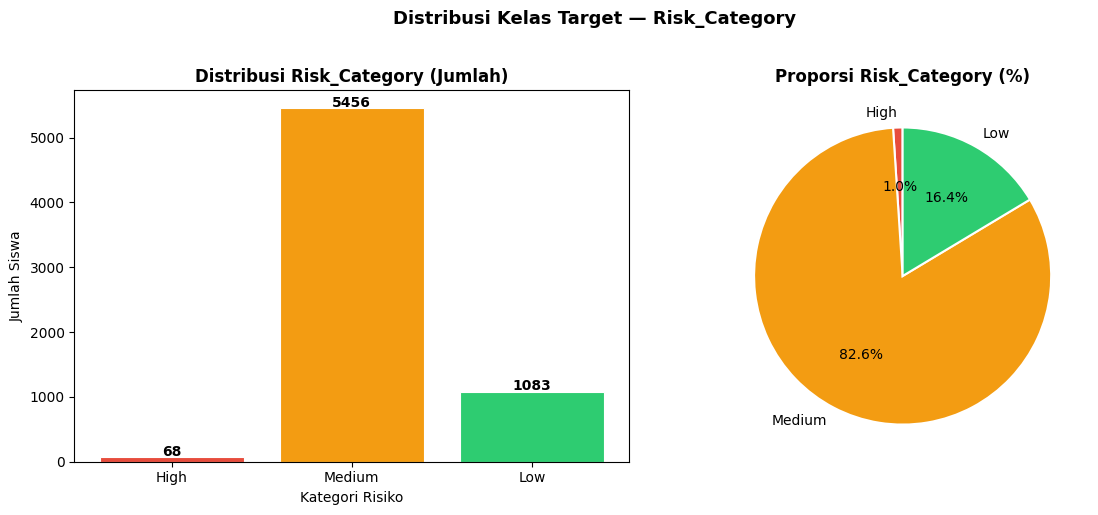

In [ ]:
# visualisasi distribusi Risk_Category
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart jumlah
counts = df_clean['Risk_Category'].value_counts().reindex(['High', 'Medium', 'Low'])
colors = ['#e74c3c', '#f39c12', '#2ecc71']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribusi Risk_Category (Jumlah)', fontweight='bold')
axes[0].set_xlabel('Kategori Risiko')
axes[0].set_ylabel('Jumlah Siswa')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# pie chart persentase
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporsi Risk_Category (%)', fontweight='bold')

plt.suptitle('Distribusi Kelas Target — Risk_Category', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **🏷️ Interpretasi: Pembentukan Variabel Target (Risk_Category)**

Kolom `Risk_Category` dibuat dari `Exam_Score` menggunakan threshold berbasis domain pendidikan Indonesia:

| Kategori | Rentang Exam_Score | Makna |
|---|---|---|
| **High** | < 60 | Di bawah ambang lulus — butuh intervensi segera |
| **Medium** | 60 – 70 | Lulus tapi di bawah rata-rata — perlu dipantau |
| **Low** | > 70 | Performa baik — tidak perlu intervensi khusus |

Threshold ini dipilih karena mencerminkan KKM (Kriteria Ketuntasan Minimal) yang umum digunakan di sekolah Indonesia, sehingga memiliki interpretasi yang langsung dapat dipahami oleh guru sebagai pengguna sistem EduPredict AI.

**Catatan untuk tim AI Engineer:** Apabila hasil distribusi menunjukkan ketidakseimbangan kelas (salah satu kategori mendominasi lebih dari 60%), perlu diterapkan teknik penyeimbangan data seperti **SMOTE** pada tahap preprocessing sebelum training model.

In [ ]:
# ekspor dataset bersih beserta kolom Risk_Category ke format CSV
output_path = 'edupredict_cleaned_v1.csv'
df_clean.to_csv(output_path, index=False)

print(f"Dataset berhasil diekspor ke '{output_path}'")
print(f"Shape akhir : {df_clean.shape[0]} baris × {df_clean.shape[1]} kolom")
print(f"Kolom       : {list(df_clean.columns)}")

Dataset berhasil diekspor ke 'edupredict_cleaned_v1.csv'
Shape akhir : 6607 baris × 21 kolom
Kolom       : ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Risk_Category']


In [ ]:
# melihat 5 data pertama dari dataset clean
df_clean.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Risk_Category
0,23,84,Low,High,No,7,73,Low,Yes,0.0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Medium
1,19,64,Low,Medium,No,8,59,Low,Yes,2.0,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Medium
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2.0,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Low
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1.0,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Low
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3.0,...,High,Public,Neutral,4,No,College,Near,Female,70,Medium


### **🏷️ Interpretasi: Ekspor Dataset Final**

Dataset `df_clean` telah diekspor ke file `edupredict_cleaned.csv` dan siap diserahkan kepada tim AI Engineer untuk proses training awal. Dataset ini mencakup 21 kolom (20 fitur asli + 1 kolom target `Risk_Category`) dengan 6.607 baris data yang telah melewati seluruh proses wrangling.

File ini merupakan sumber data tunggal (*single source of truth*) yang akan digunakan oleh seluruh learning path — tim AI Engineer untuk training model, tim Data Science untuk EDA lanjutan, dan tim Full-Stack untuk referensi struktur data pada database.

# **Pertanyaan Bisnis Terukur**

Pada tahap ini, mendefinisikan pertanyaan bisnis yang dapat diukur berarti merumuskan pertanyaan spesifik yang jawabannya bisa dinyatakan dalam bentuk angka atau metrik berdasarkan data yang tersedia. Tujuannya agar analisis data terarah, hasilnya objektif, dan keberhasilan proyek dapat dievaluasi secara jelas